In [74]:
import random
import numpy as np
import os
from os import path
import time
import copy
import torch
from torch import nn
from gan_training.utils4nb import return_data_test
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gan_training import utils
from gan_training.train import Trainer, update_average
from gan_training.logger import Logger
from gan_training.checkpoints import CheckpointIO
from gan_training.inputs import get_dataset
from gan_training.distributions import get_ydist, get_zdist
from gan_training.eval_test import DisentEvaluator, Evaluator
from gan_training.config4nb import (
    load_config, build_models, build_optimizers, build_lr_scheduler,
)


In [75]:

# Arguments

#args.config_dir='./configs'
config='cells_650.yaml'
VAEname= 'FactorVAE3'
#VAEname='BetaVAE_H'
chkptname= 'last'
config_dir='./configs'
output_dir= './outputs/'
#dvae_name= None
                   


In [76]:
#LC-136
#CellCycle-
#CPA-176-
#EMT-164-
#LiveCell -157


config_path = os.path.join(config_dir, config)
config = load_config(config_path)

nf=-1 #Base number of filters


bs=1 #'Batch size'
reg_param=-1 #'R1 regularization parameter'
w_info =-1#'weighting constant on ID Loss')
mi=max_iter=-1 #'Max training iteration')
num_workers=0 #'dataloader num_workers'
#batch_size=32 # help='batch size'

image_size= 256         #  Image size
dset_dir='C:/Users/Rashmi/WorkingLibs/MorphoGenie-Temp2/MorphoGenie/ProcessedData/'
datatype='rgb'
nc= 3

#parser.add_argument('--img_size', default=128, type=int, help='Image synthesis size')##This is the image size for which the autoencoder is designed to


c_dim= 10 #Latent synthesis size'
z_dim=256 #type=int, help='Image synthesis size')

no_cuda=False #help='Do not use cuda')
seed=1 #type=int, help='Random Seed')
infodistil_mode=True #'Infodistill')
#args = parser.parse_args()

#dvae_name='cells_trial_factor176' 
#name='GAN_Trial176_1'
TrainDataset='EMT' 
TestDataset='EMT/Orig/Vimentin/'
Model_dir='./Models'
dset_dir='./ProcessedData/'
#config_path = os.path.join(config_dir, config)
is_cuda = (torch.cuda.is_available() and not no_cuda)


In [77]:
VAE_chkptname='last'
GAN_chkptname='model.pt'
data_dir=os.path.join(dset_dir,TestDataset)
#out_dir = os.path.join(output_dir, name)
fvae_ckpt_path = os.path.join(Model_dir, TrainDataset, 'VAE','chkpts',VAE_chkptname)
gan_ckpt_path = os.path.join(Model_dir, TrainDataset, 'GAN','chkpts')
     


In [78]:

# Logger
checkpoint_io = CheckpointIO(
    checkpoint_dir=gan_ckpt_path
)

device = torch.device("cuda:0" if is_cuda else "cpu")

train_dataset = get_dataset(
    name='image',
    data_dir=data_dir,
    size=image_size,
)
train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=bs,
        num_workers=3,
        shuffle=True, pin_memory=True, sampler=None, drop_last=True
)



In [79]:
device = torch.device("cuda:0" if is_cuda else "cpu")
device

device(type='cuda', index=0)

In [80]:


#Create models
fvae, generator, discriminator = build_models(image_size, c_dim, nc, z_dim)
data_loader = return_data_test(TestDataset, datatype, dset_dir, bs, image_size)



In [81]:
selectVAE='fvae'

if selectVAE=='dvae':
    dvae_ckpt_path =  os.path.join()

    dvae_ckpt = torch.load(dvae_ckpt_path)
    #for key in list(dvae_ckpt_path.keys()):
    #    dvae_ckpt_path[key.replace('decoder.', 'module.decoder.'). replace('encoder.', 'module.encoder.')] = dvae_ckpt_path.pop(key)

    dvae.load_state_dict(dvae_ckpt_path)
else:

    #fvae_ckpt_path = os.path.join(output_dir, dvae_name,'chkpts', chkptname)

    fvae_ckpt = torch.load(fvae_ckpt_path)

    for key in list(fvae_ckpt['model_states']['VAE'].keys()):
        fvae_ckpt['model_states']['VAE'][key.replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.')] = fvae_ckpt['model_states']['VAE'].pop(key)


    fvae.load_state_dict(fvae_ckpt['model_states']['VAE'])

    dvae=fvae


In [82]:
fvae_ckpt

{'iter': 130000,
 'model_states': {'D': OrderedDict([('net.0.weight',
                tensor([[ 0.0064, -0.0531,  0.0116,  ..., -0.0016,  0.0754, -0.0853],
                        [-0.0239,  0.0534,  0.0076,  ..., -0.0323, -0.0150, -0.0194],
                        [-0.0179,  0.0207, -0.0231,  ..., -0.0165, -0.0521, -0.0253],
                        ...,
                        [ 0.0607,  0.0229, -0.0251,  ..., -0.0315,  0.0027, -0.0261],
                        [ 0.0196,  0.0250, -0.0346,  ..., -0.0153, -0.0028,  0.0148],
                        [-0.0080,  0.0451, -0.0357,  ...,  0.0266, -0.0197,  0.0363]],
                       device='cuda:0')),
               ('net.0.bias',
                tensor([-6.5851e-03,  2.5816e-02, -3.6801e-02,  1.1762e-02, -3.3811e-02,
                        -2.2181e-02, -3.8889e-02,  1.1960e-02,  1.0674e-02, -1.7584e-02,
                         3.5820e-02,  2.4549e-02,  2.3936e-03, -2.0300e-02,  1.8029e-02,
                         1.4716e-02, -8.2772e

In [83]:
# Put models on gpu if needed
dvae = dvae.to(device)
generator = generator.to(device)
discriminator = discriminator.to(device)

#g_optimizer, d_optimizer = build_optimizers(
#    generator, discriminator, dvae, config
#)

# Use multiple GPUs if possible
dvae = nn.DataParallel(dvae)
generator = nn.DataParallel(generator)
discriminator = nn.DataParallel(discriminator)

In [84]:
generator

DataParallel(
  (module): Generator(
    (fc): Linear(in_features=266, out_features=8192, bias=True)
    (resnet): Sequential(
      (0): ResnetBlock(
        (conv_0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1): Upsample(scale_factor=2.0, mode=nearest)
      (2): ResnetBlock(
        (conv_0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (3): Upsample(scale_factor=2.0, mode=nearest)
      (4): ResnetBlock(
        (conv_0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (5): Upsample(scale_factor=2.0, mode=nearest)
      (6): ResnetBlock(
        (conv_0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [85]:
discriminator

DataParallel(
  (module): Discriminator(
    (conv_img): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (resnet): Sequential(
      (0): ResnetBlock(
        (conv_0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1): AvgPool2d(kernel_size=3, stride=2, padding=1)
      (2): ResnetBlock(
        (conv_0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_s): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (3): AvgPool2d(kernel_size=3, stride=2, padding=1)
      (4): ResnetBlock(
        (conv_0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_s): Conv2d(128, 256, kernel_size=(1, 1), strid

In [86]:

# Register modules to checkpoint
checkpoint_io.register_modules(
    generator=generator,
    discriminator=discriminator,

)

# Logger
logger = Logger(
    log_dir=path.join(output_dir, 'logs'),
    img_dir=path.join(output_dir, 'imgs'),
    #monitoring=config['training']['monitoring'],
    #monitoring_dir=path.join(out_dir, 'monitoring')
)


# Distributions
cdist = get_zdist('gauss',c_dim, device=device)
zdist = get_zdist('gauss', z_dim,
                  device=device)

 
# Save for tests
ntest = bs
#x_real, ytest = utils.get_nsamples(train_loader, ntest)
ztest = zdist.sample((ntest,))
ctest = cdist.sample((ntest,))
ztest_ = torch.cat([ztest, ctest], 1)

In [87]:



generator_test = generator

# Evaluator
dis_evaluator = DisentEvaluator(generator=generator_test, zdist=zdist, cdist=cdist,
                                batch_size=bs, device=device, dvae=dvae)
#data_loader = return_data_test()

# Train
tstart = t0 = time.time()
it = epoch_idx = -1

In [88]:
generator_test

DataParallel(
  (module): Generator(
    (fc): Linear(in_features=266, out_features=8192, bias=True)
    (resnet): Sequential(
      (0): ResnetBlock(
        (conv_0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1): Upsample(scale_factor=2.0, mode=nearest)
      (2): ResnetBlock(
        (conv_0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (3): Upsample(scale_factor=2.0, mode=nearest)
      (4): ResnetBlock(
        (conv_0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv_1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (5): Upsample(scale_factor=2.0, mode=nearest)
      (6): ResnetBlock(
        (conv_0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [89]:
# Load checkpoint if existant
it = checkpoint_io.load('model.pt')
#if it != -1:
#   logger.load_stats('stats.p')
# Training loop


=> Loading checkpoint...


In [90]:
it

24367

In [94]:
epoch_idx=0
mu_real_Dump=[]
mu_gen_Dump=[]
mu_real_All=[]
mu_gen_All=[]
label1=[]
label2=[]
label3=[]
travN_MainDir='./outputs/TraversalLoop/'
#travN_MainDir= 'Z:/COVID-FTP/Rashmi/IDGAN/outputs/'
Traverse=True



In [95]:
t = time.time()
for x_true, path, label in data_loader:
    epoch_idx += 1

    #for x_real, _ in train_loader:
    
    x_true=x_true.to(device)

    mu_real, logvar, c_real = fvae(x_true, encode_only=True)
    #print(c_real)
    
    recon_img=dis_evaluator.predict_image(c_real)
    recon_img=torch.stack(recon_img)
    mu_gen, logvar_gen, c_gen=fvae(recon_img, encode_only=True)
    
    mu_real_All.append(mu_real.detach().cpu())
    mu_gen_All.append(mu_gen.detach().cpu())
    
    
    mu, c_lat=dis_evaluator.predict_latent(x_true)
    if Traverse==True:
        if epoch_idx < 50:
        
            travN =  epoch_idx
            travN_dir = os.path.join(travN_MainDir, str(travN))
            #print('checkpoint_dir',checkpoint_dir)
            # Create missing directories
            if not os.path.exists(travN_dir):
                os.makedirs(travN_dir)
                
            c_lat_sample=c_lat
            z_sample=ztest[0]
            #c_lat_sample=c_lat_sample.unsqueeze(0)
            z_sample=z_sample.unsqueeze(0)
            travN
            ncol=dis_evaluator.traverse_c1z1(travN, z_sample, c_lat_sample, save='False', save_type='dvae', TravImRet=Traverse, cmap='viridis')
            print('Saving Traversal Images')
    print(epoch_idx)
## Sorting the feature tables according to order generated in the ImageGenerator 

    label1.append(label)
    L1=os.path.split(path[0])
    L2=os.path.basename(path[0])

    Name=L2[0]
    label2.append(Name[0])
    label3.append(path)

            
    # do stuff
elapsed = time.time() - t
print('Time taken to complete testing this dataset=')
print(elapsed)

Saving Traversal Images
1
Saving Traversal Images
2
Saving Traversal Images
3
Saving Traversal Images
4
Saving Traversal Images
5
Saving Traversal Images
6
Saving Traversal Images
7
Saving Traversal Images
8
Saving Traversal Images
9
Saving Traversal Images
10
Saving Traversal Images
11
Saving Traversal Images
12
Saving Traversal Images
13
Saving Traversal Images
14
Saving Traversal Images
15
Saving Traversal Images
16
Saving Traversal Images
17
Saving Traversal Images
18
Saving Traversal Images
19
Saving Traversal Images
20
Saving Traversal Images
21
Saving Traversal Images
22
Saving Traversal Images
23
Saving Traversal Images
24
Saving Traversal Images
25
Saving Traversal Images
26
Saving Traversal Images
27
Saving Traversal Images
28
Saving Traversal Images
29
Saving Traversal Images
30
Saving Traversal Images
31
Saving Traversal Images
32
Saving Traversal Images
33
Saving Traversal Images
34
Saving Traversal Images
35
Saving Traversal Images
36
Saving Traversal Images
37
Saving Tra

1627
1628
1629
1630
1631
1632
1633
1634
1635
1636
1637
1638
1639
1640
1641
1642
1643
1644
1645
1646
1647
1648
1649
1650
1651
1652
1653
1654
1655
1656
1657
1658
1659
1660
1661
1662
1663
1664
1665
1666
1667
1668
1669
1670
1671
1672
1673
1674
1675
1676
1677
1678
1679
1680
1681
1682
1683
1684
1685
1686
1687
1688
1689
1690
1691
1692
1693
1694
1695
1696
1697
1698
1699
1700
1701
1702
1703
1704
1705
1706
1707
1708
1709
1710
1711
1712
1713
1714
1715
1716
1717
1718
1719
1720
1721
1722
1723
1724
1725
1726
1727
1728
1729
1730
1731
1732
1733
1734
1735
1736
1737
1738
1739
1740
1741
1742
1743
1744
1745
1746
1747
1748
1749
1750
1751
1752
1753
1754
1755
1756
1757
1758
1759
1760
1761
1762
1763
1764
1765
1766
1767
1768
1769
1770
1771
1772
1773
1774
1775
1776
1777
1778
1779
1780
1781
1782
1783
1784
1785
1786
1787
1788
1789
1790
1791
1792
1793
1794
1795
1796
1797
1798
1799
1800
1801
1802
1803
1804
1805
1806
1807
1808
1809
1810
1811
1812
1813
1814
1815
1816
1817
1818
1819
1820
1821
1822
1823
1824
1825
1826


3275
3276
3277
3278
3279
3280
3281
3282
3283
3284
3285
3286
3287
3288
3289
3290
3291
3292
3293
3294
3295
3296
3297
3298
3299
3300
3301
3302
3303
3304
3305
3306
3307
3308
3309
3310
3311
3312
3313
3314
3315
3316
3317
3318
3319
3320
3321
3322
3323
3324
3325
3326
3327
3328
3329
3330
3331
3332
3333
3334
3335
3336
3337
3338
3339
3340
3341
3342
3343
3344
3345
3346
3347
3348
3349
3350
3351
3352
3353
3354
3355
3356
3357
3358
3359
3360
3361
3362
3363
3364
3365
3366
3367
3368
3369
3370
3371
3372
3373
3374
3375
3376
3377
3378
3379
3380
3381
3382
3383
3384
3385
3386
3387
3388
3389
3390
3391
3392
3393
3394
3395
3396
3397
3398
3399
3400
3401
3402
3403
3404
3405
3406
3407
3408
3409
3410
3411
3412
3413
3414
3415
3416
3417
3418
3419
3420
3421
3422
3423
3424
3425
3426
3427
3428
3429
3430
3431
3432
3433
3434
3435
3436
3437
3438
3439
3440
3441
3442
3443
3444
3445
3446
3447
3448
3449
3450
3451
3452
3453
3454
3455
3456
3457
3458
3459
3460
3461
3462
3463
3464
3465
3466
3467
3468
3469
3470
3471
3472
3473
3474


4920
4921
4922
4923
4924
4925
4926
4927
4928
4929
4930
4931
4932
4933
4934
4935
4936
4937
4938
4939
4940
4941
4942
4943
4944
4945
4946
4947
4948
4949
4950
4951
4952
4953
4954
4955
4956
4957
4958
4959
4960
4961
4962
4963
4964
4965
4966
4967
4968
4969
4970
4971
4972
4973
4974
4975
4976
4977
4978
4979
4980
4981
4982
4983
4984
4985
4986
4987
4988
4989
4990
4991
4992
4993
4994
4995
4996
4997
4998
4999
5000
5001
5002
5003
5004
5005
5006
5007
5008
5009
5010
5011
5012
5013
5014
5015
5016
5017
5018
5019
5020
5021
5022
5023
5024
5025
5026
5027
5028
5029
5030
5031
5032
5033
5034
5035
5036
5037
5038
5039
5040
5041
5042
5043
5044
5045
5046
5047
5048
5049
5050
5051
5052
5053
5054
5055
5056
5057
5058
5059
5060
5061
5062
5063
5064
5065
5066
5067
5068
5069
5070
5071
5072
5073
5074
5075
5076
5077
5078
5079
5080
5081
5082
5083
5084
5085
5086
5087
5088
5089
5090
5091
5092
5093
5094
5095
5096
5097
5098
5099
5100
5101
5102
5103
5104
5105
5106
5107
5108
5109
5110
5111
5112
5113
5114
5115
5116
5117
5118
5119


6559
6560
6561
6562
6563
6564
6565
6566
6567
6568
6569
6570
6571
6572
6573
6574
6575
6576
6577
6578
6579
6580
6581
6582
6583
6584
6585
6586
6587
6588
6589
6590
6591
6592
6593
6594
6595
6596
6597
6598
6599
6600
6601
6602
6603
6604
6605
6606
6607
6608
6609
6610
6611
6612
6613
6614
6615
6616
6617
6618
6619
6620
6621
6622
6623
6624
6625
6626
6627
6628
6629
6630
6631
6632
6633
6634
6635
6636
6637
6638
6639
6640
6641
6642
6643
6644
6645
6646
6647
6648
6649
6650
6651
6652
6653
6654
6655
6656
6657
6658
6659
6660
6661
6662
6663
6664
6665
6666
6667
6668
6669
6670
6671
6672
6673
6674
6675
6676
6677
6678
6679
6680
6681
6682
6683
6684
6685
6686
6687
6688
6689
6690
6691
6692
6693
6694
6695
6696
6697
6698
6699
6700
6701
6702
6703
6704
6705
6706
6707
6708
6709
6710
6711
6712
6713
6714
6715
6716
6717
6718
6719
6720
6721
6722
6723
6724
6725
6726
6727
6728
6729
6730
6731
6732
6733
6734
6735
6736
6737
6738
6739
6740
6741
6742
6743
6744
6745
6746
6747
6748
6749
6750
6751
6752
6753
6754
6755
6756
6757
6758


...

12610
12611
12612
12613
12614
12615
12616
12617
12618
12619
12620
12621
12622
12623
12624
12625
12626
12627
12628
12629
12630
12631
12632
12633
12634
12635
12636
12637
12638
12639
12640
12641
12642
12643
12644
12645
12646
12647
12648
12649
12650
12651
12652
12653
12654
12655
12656
12657
12658
12659
12660
12661
12662
12663
12664
12665
12666
12667
12668
12669
12670
12671
12672
12673
12674
12675
12676
12677
12678
12679
12680
12681
12682
12683
12684
12685
12686
12687
12688
12689
12690
12691
12692
12693
12694
12695
12696
12697
12698
12699
12700
12701
12702
12703
12704
12705
12706
12707
12708
12709
12710
12711
12712
12713
12714
12715
12716
12717
12718
12719
12720
12721
12722
12723
12724
12725
12726
12727
12728
12729
12730
12731
12732
12733
12734
12735
12736
12737
12738
12739
12740
12741
12742
12743
12744
12745
12746
12747
12748
12749
12750
12751
12752
12753
12754
12755
12756
12757
12758
12759
12760
12761
12762
12763
12764
12765
12766
12767
12768
12769
12770
12771
12772
12773
12774
12775
1277

13983
13984
13985
13986
13987
13988
13989
13990
13991
13992
13993
13994
13995
13996
13997
13998
13999
14000
14001
14002
14003
14004
14005
14006
14007
14008
14009
14010
14011
14012
14013
14014
14015
14016
14017
14018
14019
14020
14021
14022
14023
14024
14025
14026
14027
14028
14029
14030
14031
14032
14033
14034
14035
14036
14037
14038
14039
14040
14041
14042
14043
14044
14045
14046
14047
14048
14049
14050
14051
14052
14053
14054
14055
14056
14057
14058
14059
14060
14061
14062
14063
14064
14065
14066
14067
14068
14069
14070
14071
14072
14073
14074
14075
14076
14077
14078
14079
14080
14081
14082
14083
14084
14085
14086
14087
14088
14089
14090
14091
14092
14093
14094
14095
14096
14097
14098
14099
14100
14101
14102
14103
14104
14105
14106
14107
14108
14109
14110
14111
14112
14113
14114
14115
14116
14117
14118
14119
14120
14121
14122
14123
14124
14125
14126
14127
14128
14129
14130
14131
14132
14133
14134
14135
14136
14137
14138
14139
14140
14141
14142
14143
14144
14145
14146
14147
14148
1414

15350
15351
15352
15353
15354
15355
15356
15357
15358
15359
15360
15361
15362
15363
15364
15365
15366
15367
15368
15369
15370
15371
15372
15373
15374
15375
15376
15377
15378
15379
15380
15381
15382
15383
15384
15385
15386
15387
15388
15389
15390
15391
15392
15393
15394
15395
15396
15397
15398
15399
15400
15401
15402
15403
15404
15405
15406
15407
15408
15409
15410
15411
15412
15413
15414
15415
15416
15417
15418
15419
15420
15421
15422
15423
15424
15425
15426
15427
15428
15429
15430
15431
15432
15433
15434
15435
15436
15437
15438
15439
15440
15441
15442
15443
15444
15445
15446
15447
15448
15449
15450
15451
15452
15453
15454
15455
15456
15457
15458
15459
15460
15461
15462
15463
15464
15465
15466
15467
15468
15469
15470
15471
15472
15473
15474
15475
15476
15477
15478
15479
15480
15481
15482
15483
15484
15485
15486
15487
15488
15489
15490
15491
15492
15493
15494
15495
15496
15497
15498
15499
15500
15501
15502
15503
15504
15505
15506
15507
15508
15509
15510
15511
15512
15513
15514
15515
1551

16718
16719
16720
16721
16722
16723
16724
16725
16726
16727
16728
16729
16730
16731
16732
16733
16734
16735
16736
16737
16738
16739
16740
16741
16742
16743
16744
16745
16746
16747
16748
16749
16750
16751
16752
16753
16754
16755
16756
16757
16758
16759
16760
16761
16762
16763
16764
16765
16766
16767
16768
16769
16770
16771
16772
16773
16774
16775
16776
16777
16778
16779
16780
16781
16782
16783
16784
16785
16786
16787
16788
16789
16790
16791
16792
16793
16794
16795
16796
16797
16798
16799
16800
16801
16802
16803
16804
16805
16806
16807
16808
16809
16810
16811
16812
16813
16814
16815
16816
16817
16818
16819
16820
16821
16822
16823
16824
16825
16826
16827
16828
16829
16830
16831
16832
16833
16834
16835
16836
16837
16838
16839
16840
16841
16842
16843
16844
16845
16846
16847
16848
16849
16850
16851
16852
16853
16854
16855
16856
16857
16858
16859
16860
16861
16862
16863
16864
16865
16866
16867
16868
16869
16870
16871
16872
16873
16874
16875
16876
16877
16878
16879
16880
16881
16882
16883
1688

18089
18090
18091
18092
18093
18094
18095
18096
18097
18098
18099
18100
18101
18102
18103
18104
18105
18106
18107
18108
18109
18110
18111
18112
18113
18114
18115
18116
18117
18118
18119
18120
18121
18122
18123
18124
18125
18126
18127
18128
18129
18130
18131
18132
18133
18134
18135
18136
18137
18138
18139
18140
18141
18142
18143
18144
18145
18146
18147
18148
18149
18150
18151
18152
18153
18154
18155
18156
18157
18158
18159
18160
18161
18162
18163
18164
18165
18166
18167
18168
18169
18170
18171
18172
18173
18174
18175
18176
18177
18178
18179
18180
18181
18182
18183
18184
18185
18186
18187
18188
18189
18190
18191
18192
18193
18194
18195
18196
18197
18198
18199
18200
18201
18202
18203
18204
18205
18206
18207
18208
18209
18210
18211
18212
18213
18214
18215
18216
18217
18218
18219
18220
18221
18222
18223
18224
18225
18226
18227
18228
18229
18230
18231
18232
18233
18234
18235
18236
18237
18238
18239
18240
18241
18242
18243
18244
18245
18246
18247
18248
18249
18250
18251
18252
18253
18254
1825

In [116]:
    #label1.append(label)
    L1=os.path.split(path[0])
    L2=os.path.basename(path[0])
    Name=L2[0]
    
    #label2.append(Name)
    #label3.append(path)
    #print(label)
    print(path)
    #print(path)

['./ProcessedData/EMT/Orig/Vimentin/Mesenchymal\\M\\9986.png']


In [96]:

label1=np.hstack(label1)
label2=np.hstack(label2)
label3=np.hstack(label3)

label=label2

mu_real_All=np.vstack(mu_real_All)
LatentZ=pd.DataFrame(mu_real_All)
'''LatentZ.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Latent_EMT_Lineage2.csv')
LabelAll=pd.DataFrame(label1)
LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_lineage2.csv')
LabelAll=pd.DataFrame(label2)
LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineage_Cond2.csv')
LabelAll=pd.DataFrame(label3)
LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineages_Paths2.csv')'''



"LatentZ.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Latent_EMT_Lineage2.csv')\nLabelAll=pd.DataFrame(label1)\nLabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_lineage2.csv')\nLabelAll=pd.DataFrame(label2)\nLabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineage_Cond2.csv')\nLabelAll=pd.DataFrame(label3)\nLabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineages_Paths2.csv')"

In [117]:
embedding=dis_evaluator.reduce_latent2d(dis_evaluator.normalize_matrix(mu_real_All), dim_red='umap')


In [123]:
sns.set(font_scale = 5)
#data_real=np.hstack((embedding, labelAll[:]))
df1 = pd.DataFrame(embedding, columns=['X','Y'])
df2 = pd.DataFrame(label1, columns=['ClassLabels1'])
df3 = pd.DataFrame(label2, columns=['ClassLabels2'])
df_F=pd.concat([df1, df2, df3],axis=1)

In [124]:
mu_real_All=np.vstack(mu_real_All)
#LatentZ=pd.DataFrame(mu_real_All)
#LatentZ.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Latent_EMT_path.csv')

#df_F.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_path.csv')


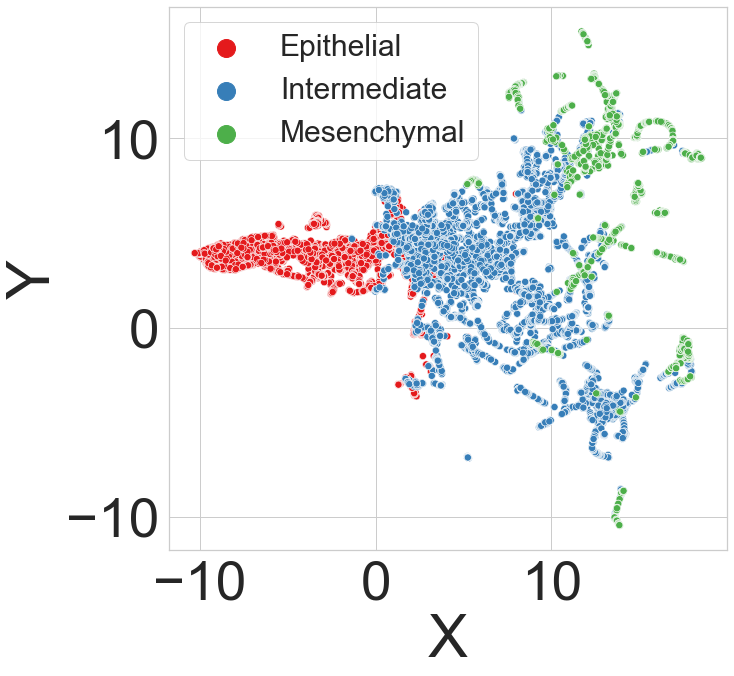

In [129]:
plt.figure(figsize=(10,10))
#plt.axis('off')
sns.set_style("whitegrid")

sns.scatterplot(data=df_F, x="X", y="Y", s=50, hue="ClassLabels1", palette=('Set1'))
plt.legend(markerscale=3, fontsize=30)

In [134]:
mu_real_All.shape

(19259, 10)

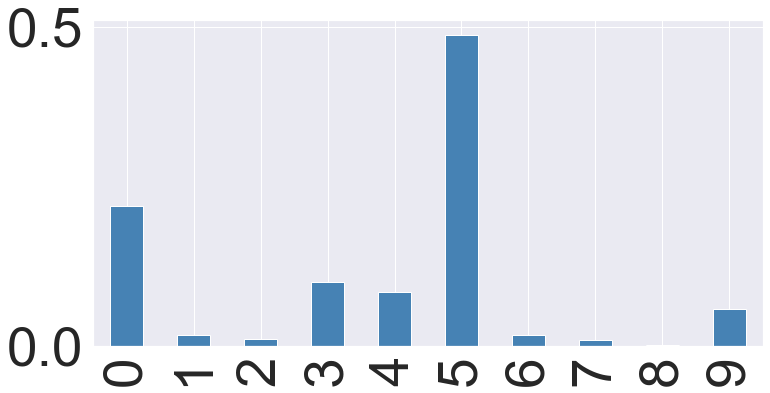

Accuracy: 0.9273104880581516


In [136]:
sns.set(font_scale=5)

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import pandas as pd
plt.grid(None)
df_mu_real_All=pd.DataFrame(mu_real_All)
#plt.axis('off')
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(mu_real_All, label1, test_size=0.2, random_state=1)
clf = DecisionTreeClassifier(criterion='gini', max_depth=7)
clf.fit(X_train, y_train)  # celltype
pd.Series(clf.feature_importances_, index=df_mu_real_All.columns).plot.bar(color='steelblue', figsize=(12, 6))
plt.show()
y_pred = clf.predict(X_test)


print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

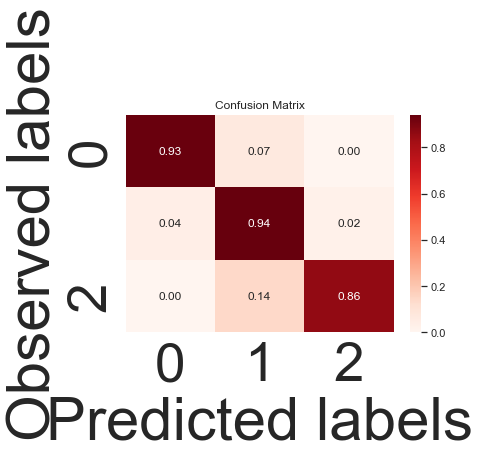

In [137]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix,plot_confusion_matrix

ax = plt.subplot()
sns.set(font_scale=1.0) # Adjust to fit
y_pred= clf.predict(X_test)

cm=confusion_matrix(y_test, y_pred)

df=pd.DataFrame(cm)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cmn, annot=True, fmt='.2f', ax=ax, cmap="Reds");  # annot=True to annotate cells

#plt.axis('off')

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('Observed labels');
ax.set_title('Confusion Matrix');
#ax.xaxis.set_ticklabels(label1);
#ax.yaxis.set_ticklabels(label1);


plt.show()